In [1]:
import numpy as np
import sys
from pathlib import Path

sys.path.append('../code/')

from mlalgos import HyperOpt
from mllib import Utilities,MLUtilities

from time import time
import copy,pickle

import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol
import gc

from sklearn.datasets import make_moons

ut = Utilities()
ml = MLUtilities()

In [2]:
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14 # 14
mpl.rcParams['legend.labelspacing'] = 0.25
FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3

#mpl.rcParams.keys()

# Example usage of `HyperOpt` 
### for systematically searching over network architectures and hyperparameters

In [3]:
Plot_Stem = 'hyperopt/plots'
Path(Plot_Stem).mkdir(parents=True,exist_ok=True)

Family = 'biseq'

Nproc = 16

Save_Fig = True

In [4]:
Shallow = False # True: shallow+wide arch; False: deep+narrow arch; None: telescoping arch
Fixed_Width = True # can be False for deep networks

Standardize_X = True # whether or not to standardize features
Standardize_Y = True # whether or not to standardize labels (only relevant for regression)

Decay_Norm = 2 # 1 or 2

if Shallow is not None:
    Depth_Str_Root = 'shallow' if Shallow else 'deep'
    if Shallow:
        Fixed_Width = True # don't randomize widths in shallow networks
else:
    Depth_Str_Root = 'telescopic'
    Fixed_Width = None
Plot_Str_Root = '' + Depth_Str_Root

DN_Str = '/dn{0:d}'.format(Decay_Norm)

if Standardize_X:
    if Standardize_Y:
        Std_Str = 'stdXstdY'
    else:
        Std_Str = 'stdX'
else:
    if Standardize_Y:
        Std_Str = 'stdY'
    else:
        Std_Str = 'nostd'
Depth_Str = Depth_Str_Root + '/' + Std_Str
Plot_Str_Root += '_' + Std_Str
print(Depth_Str,Plot_Str_Root)

Std_Text = 'std: '
if Standardize_X:
    Std_Text += 'X,Y' if Standardize_Y else 'X'
else:
    Std_Text += 'Y' if Standardize_Y else 'none'

deep/stdXstdY deep_stdXstdY


## Regression example: 1-d Gaussian, power-sine families
**useful for `Sequential` and `BiSequential`**

### Function definitions

In [5]:
def func_gauss1d(x,params):
    """ Expect x as 1-d array, params as array of shape (0,) or (1,). """
    mu = params[0] if len(params) > 0 else 0.0
    sig2 = 10**params[1] if len(params) > 1 else 1.0
    return np.exp(-0.5*(x-mu)**2/sig2)/np.sqrt(2*np.pi*sig2)

def func_powersine(x,params):
    """ Expect x as 1-d array, params as array of shape (0,), (1,) or (2,). """
    A = params[0] if len(params) > 0 else 1.0
    exponent = params[1] if len(params) > 1 else 0.0
    phase = params[2] if len(params) > 2 else 0.0
    return A*np.fabs(x)**exponent*np.sin(x + phase)**2

### Training & testing samples

In [6]:
Ftype = 'gf1d'

ExDict = {'gf1d':{'root':'gf1d/','text':'1-d Gaussian',
                  'func':func_gauss1d,'xbounds':[-2.5,3.0],
                  'pbounds':{'min':[-0.3,-0.1], # minimum mu,lgsig2
                             'max':[ 0.3, 0.1]} # maximum mu,lgsig2
                 },
          'psin':{'root':'psin/','text':'Power-Sine',
                  'func':func_powersine,'xbounds':[0.0,1.5*np.pi],
                  'pbounds':{'min':[-1.0,0.0,-np.pi/9], # minimum A,expo,phase
                             'max':[ 1.0,0.2, np.pi/9]} # maximum A,expo,phase
                 }
         }

if Ftype not in ExDict.keys():
    raise Exception("FType must be one of ["+','.join(key for key in list(ExDict.keys()))+']')

Example_Root = Family + '/' + ExDict[Ftype]['root'] + Depth_Str + DN_Str
Plot_Root = Family + '_' + ExDict[Ftype]['root'][:-1] + '_' + Plot_Str_Root + '_' + DN_Str[1:]
if Shallow == False:
    FW_Str = 'fixwid' if Fixed_Width else 'ranwid'
    Example_Root += '/' + FW_Str
    Plot_Root += '_' + FW_Str
print(Example_Root,Plot_Root)

Example_Text = ExDict[Ftype]['text']

example_func = ExDict[Ftype]['func']
xmin,xmax = ExDict[Ftype]['xbounds']
param_mins = ExDict[Ftype]['pbounds']['min'] 
param_maxs = ExDict[Ftype]['pbounds']['max'] 


biseq/gf1d/deep/stdXstdY/dn2/fixwid biseq_gf1d_deep_stdXstdY_dn2_fixwid


Generating data for 1-d Gaussian family...
... training sample
... sorted training sample by standardized central distance
... sample of size 45000 created
... testing sample
... sample of size 15000 created
... done
0 min 0.17 seconds

Writing to file: hyperopt/plots/gf1d.png
(3, 45000) (1, 45000)


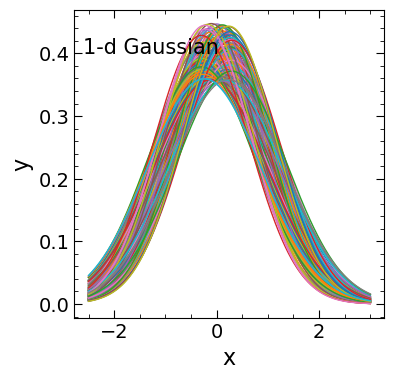

In [32]:
start_time = time()

print('Generating data for '+Example_Text+' family...')

seed = 1983
rng = np.random.RandomState(seed)

#################################################
# Training set
print('... training sample')
n_x_train = 300
xtrain = np.linspace(xmin,xmax,n_x_train)

n_lhc_train = 150 # no. of Latin hypercube samples
n_params = len(param_mins)

# LHC of shape (n_lhc_train,n_params)
if len(param_mins) > 0:
    params_train = ut.gen_latin_hypercube(Nsamp=n_lhc_train,dim=n_params,param_mins=param_mins,param_maxs=param_maxs,rng=rng) 
else:
    params_train = [[]]

cent_dist = params_train - np.mean(params_train,axis=0,keepdims=True)
cent_dist /= np.std(params_train,axis=0,keepdims=True)
# print(cent_dist.shape,np.mean(cent_dist,axis=0),np.std(cent_dist,axis=0))
cent_dist = np.sum(cent_dist**2,axis=1)
cent_dist = np.sqrt(cent_dist)
sorter = np.argsort(cent_dist)
params_train = params_train[sorter]
del sorter
gc.collect()
print('... sorted training sample by standardized central distance')


n_train = n_lhc_train*n_x_train

X_train = np.zeros((n_train,n_params+1)) # features = {params},x (consistent with BiSequential requirement); X will be transposed later
Y_train = np.zeros((1,n_train))

for n in range(n_lhc_train):
    sl = np.s_[n*n_x_train:(n+1)*n_x_train]
    for p in range(n_params):
        X_train[sl,p] = params_train[n,p]
    X_train[sl,-1] = xtrain
    Y_train[0,sl] = example_func(xtrain,params_train[n])

X_train = X_train.T
print('... sample of size {0:d} created'.format(n_train))

#################################################
# Testing set
print('... testing sample')
n_x_test = 200
xtest = (xmax-xmin)*rng.random_sample(n_x_test) + xmin

n_lhc_test = 75 # no. of Latin hypercube samples

# LHC of shape (n_lhc_test,n_params)
if len(param_mins) > 0:
    params_test = ut.gen_latin_hypercube(Nsamp=n_lhc_test,dim=n_params,param_mins=param_mins,param_maxs=param_maxs,rng=rng) 
else:
    params_test = [[]]

n_test = n_lhc_test*n_x_test

X_test = np.zeros((n_test,n_params+1)) # features = {params},x; X will be transposed later
Y_test = np.zeros((1,n_test))

for n in range(n_lhc_test):
    sl = np.s_[n*n_x_test:(n+1)*n_x_test]
    for p in range(n_params):
        X_test[sl,p] = params_test[n,p]
    X_test[sl,-1] = xtest
    Y_test[0,sl] = example_func(xtest,params_test[n])

X_test = X_test.T
print('... sample of size {0:d} created'.format(n_test))
print('... done')
ut.time_this(start_time)

plt.figure(figsize=(4,4))
plt.xlabel('x')
plt.ylabel('y')
for n in range(n_lhc_train):
    sl = np.s_[n*n_x_train:(n+1)*n_x_train]
    plt.plot(xtrain,Y_train[0,sl],lw=1)
plt.text(0.1 if Ftype=='psin' else -2.6,1.0 if Ftype=='psin' else 0.4,Example_Text,fontsize=FS2)
plt.minorticks_on()
filename = Plot_Stem + '/' + Ftype + '.png'
print('Writing to file:',filename)
plt.savefig(filename,bbox_inches='tight')

print(X_train.shape,Y_train.shape)

## Classification example: Two moons
**useful for `Sequential`**

### Training & testing samples

In [8]:
if Family == 'seq':
    FtypeClass = 'moons'
    
    ExDictClass = {'moons':{'root':'moons/','text':'Two Moons',
                            'noise':0.1,'neg_labels':False}
                  }
    
    if FtypeClass not in ExDictClass.keys():
        raise Exception("FTypeClass must be one of ["+','.join(key for key in list(ExDict.keys()))+']')
    
    Example_Class_Root = Family + '/' + ExDictClass[FtypeClass]['root'] + Depth_Str + DN_Str
    Plot_Class_Root = Family + '_' + ExDictClass[FtypeClass]['root'][:-1] + '_' + Plot_Str_Root + '_' + DN_Str[1:]
    print(Example_Class_Root,Plot_Class_Root)
    
    Example_Class_Text = ExDictClass[FtypeClass]['text']
    noise = ExDictClass[FtypeClass]['noise']
    Neg_Labels = ExDictClass[FtypeClass]['neg_labels']


In [9]:
if Family == 'seq':
    start_time = time()
    
    print('Generating data for '+Example_Class_Text+' family...')
    
    seed = 1983
    rng = np.random.RandomState(seed)
    
    #################################################
    # Training set
    print('... training sample')
    nc_train = 2500
    if FtypeClass == 'moons':
        Xc_train,Yc_train = make_moons(n_samples=nc_train,noise=noise,random_state=rng)
    else:
        pass
        
    Xc_train = Xc_train.T
    Yc_train = ml.rv(Yc_train)
    
    print('... sample of size {0:d} created'.format(nc_train))
    #################################################
    # Testing set
    print('... testing sample')
    nc_test = 2000
    if FtypeClass == 'moons':
        Xc_test,Yc_test = make_moons(n_samples=nc_test,noise=noise,random_state=rng)
    else:
        pass
        
    Xc_test = Xc_test.T
    Yc_test = ml.rv(Yc_test)
    print('... sample of size {0:d} created'.format(nc_test))
    #################################################
    print('... done')
    ut.time_this(start_time)
    
    cmoon = ['crimson','indigo']
    plt.figure(figsize=(2,2))
    plt.scatter(Xc_train[0],Xc_train[1],c=[cmoon[Yc_train[0,n]] for n in range(Yc_train.shape[1])],s=0.2)
    plt.show()
    if Xc_train.shape[0] > 2:
        plt.figure(figsize=(2,2))
        plt.scatter(Xc_train[0],Xc_train[2],c=[cmoon[Yc_train[0,n]] for n in range(Yc_train.shape[1])],s=0.2)
        plt.show()
    
    plt.figure(figsize=(2,2))
    plt.scatter(Xc_test[0],Xc_test[1],c=[cmoon[Yc_test[0,n]] for n in range(Yc_test.shape[1])],s=0.4)
    plt.show()
    if Xc_test.shape[0] > 2:
        plt.figure(figsize=(2,2))
        plt.scatter(Xc_test[0],Xc_test[2],c=[cmoon[Yc_test[0,n]] for n in range(Yc_test.shape[1])],s=0.2)
        plt.show()
    print(Xc_train.shape,Yc_train.shape)
    print(Xc_test.shape,Yc_test.shape)

## Optimization of `Sequential`

### Regression example: 1-d Gaussian, power-sine families

#### Network setup and training

In [10]:
if Family == 'seq':
    # dictionary containing all setup parameters and data
    setup_dict = {} 
    
    # -- data set: features and labels
    setup_dict['X'] = X_train
    setup_dict['Y'] = Y_train
    
    # -- network family
    setup_dict['family'] = Family
    
    # -- training sample 
    setup_dict['train_frac'] = 0.8
    setup_dict['val_frac'] = 0.2
    setup_dict['loss_type'] = 'square'
    setup_dict['neg_labels'] = True # irrelevant for regression
    
    # -- training setup
    setup_dict['standardize_X'] = Standardize_X
    setup_dict['standardize_Y'] = Standardize_Y
    setup_dict['max_epoch'] = 3000 if Shallow else 10000
    setup_dict['check_after'] = 300 if Shallow else 1000
    setup_dict['decay_norm'] = Decay_Norm
    setup_dict['test_type'] = 'perc' if Ftype=='gf1d' else 'mse'
    setup_dict['seed'] = None
    setup_dict['file_stem'] = 'net' # will be changed later
    
    #-----------------------
    # total number of networks trained will be n_iter * max_config
    N_Iter = 4
    Max_Config = 96
    setup_dict['n_iter'] = N_Iter
    setup_dict['max_config'] = Max_Config
    #-----------------------
    
    setup_dict['ensemble'] = False   # will be changed
    setup_dict['ensemble_size'] = 10 # as needed
    
    setup_dict['parallel'] = True
    setup_dict['nproc'] = np.min([Nproc,N_Iter*Max_Config])
    setup_dict['fixed_width'] = Fixed_Width
    setup_dict['fixed_htype'] = True
    
    # -- sampled parameters
    setup_dict['layers'] = {'min':(2 if Shallow else 10) if Shallow is not None else 4,
                            'max':(4 if Shallow else 20) if Shallow is not None else 8}
    setup_dict['widths'] = {'min':( 50 if Shallow else 8) if Shallow is not None else 2,
                            'max':(200 if Shallow else 12) if Shallow is not None else 100}
    setup_dict['lglrates'] = {'min':-4.0,'max':-2.0}
    setup_dict['wt_decays'] = {'min':0.0,'max':0.3}
    setup_dict['thresholds'] = None
    setup_dict['htypes'] = ['tanh','relu','lrelu','sin']
    setup_dict['lrelu_slopes'] = {'min':-1e-2,'max':1e-2}
    setup_dict['reg_funs'] = ['drop','none'] 
    setup_dict['p_drops'] = {'min':0.0,'max':0.5}
    setup_dict['dream_schedules'] = None
    
    # -- I/O
    setup_dict['verbose'] = True
    setup_dict['logfile'] = None

##### Non-ensembled

In [11]:
if Family == 'seq':
    Optimize = False
    
    Example_Stem_Single = Example_Root +'/sing'
    
    File_Stem = 'hyperopt/' + Example_Stem_Single
    print('File_Stem:',File_Stem)
    
    setup_dict_sing = copy.deepcopy(setup_dict)
    setup_dict_sing['file_stem'] = File_Stem
    setup_dict_sing['ensemble'] = False
    
    start_time = time()
    hopt_sing = HyperOpt(setup_dict=setup_dict_sing)
    
    if Optimize:
        net,params_train,bts = hopt_sing.optimize()
    else:
        net = hopt_sing.load()
        params_train,bts = hopt_sing.load_train()
    
    ut.time_this(start_time)

In [12]:
if Family == 'seq':
    Ypred_sing = net.predict(X_test)
    show_keys = ['L','wt_decay','n_layer','atypes','reg_fun']
    
    print('Best test stat = {0:.3e}'.format(bts))
    print('Setup params:')
    for pkey in show_keys:
        print('... '+pkey+':',net.params[pkey])
        if pkey == 'atypes':
            if 'lrelu' in net.params[pkey]:
                print('... ... lrelu_slope: {0:.2e}'.format(net.params['lrelu_slope']))
    print('... check_after: {0:d}'.format(params_train['check_after']))
    print('... lrate: {0:.2e}'.format(params_train['lrate']))
    
    print('No. of free params optimized = {0:d}\n'.format(net.calc_N_freeparams()))
    
    plt.figure(figsize=(3,3))
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.plot(net.epochs,net.training_loss,'k-',lw=0.5,label='training')
    plt.plot(net.epochs,net.val_loss,'r-',lw=1,label='validation')
    plt.legend()
    plt.show()
    
    residual_sing = np.squeeze(Ypred_sing/(Y_test + 1e-15) - 1)


##### Ensembled

In [13]:
if Family == 'seq':
    Optimize = False
    
    Example_Stem_Ens = Example_Root +'/ens'
    
    File_Stem = 'hyperopt/' + Example_Stem_Ens
    print('File_Stem:',File_Stem)
    
    setup_dict_ens = copy.deepcopy(setup_dict)
    setup_dict_ens['file_stem'] = File_Stem
    setup_dict_ens['ensemble'] = True
    setup_dict_ens['ensemble_size'] = 10
    
    start_time = time()
    hopt_ens = HyperOpt(setup_dict=setup_dict_ens)
    
    if Optimize:
        neo = hopt_ens.optimize()
    else:
        neo = hopt_ens.load() 
    
    Ypred_ens = neo.predict(X_test)
    neo.display_summary(show_keys=['L','wt_decay','n_layer','atypes','reg_fun'])
    residual_ens = np.squeeze(Ypred_ens/(Y_test + 1e-15) - 1)
    
    ut.time_this(start_time)

##### Plot

In [14]:
if Family == 'seq':
    res_sing_16pc = np.percentile(residual_sing,16)*100
    res_sing_med  = np.median(residual_sing)*100
    res_sing_84pc = np.percentile(residual_sing,84)*100
    
    res_ens_16pc = np.percentile(residual_ens,16)*100
    res_ens_med  = np.median(residual_ens)*100
    res_ens_84pc = np.percentile(residual_ens,84)*100
    
    bins = np.linspace(-25,25,801)
    bin_mid = 0.5*(bins[1:]+bins[:-1])
    hist_sing,bins = np.histogram(residual_sing*100,bins=bins,density=False)
    hist_sing = hist_sing/residual_sing.size/(bins[1]-bins[0])
    hist_ens,bins = np.histogram(residual_ens*100,bins=bins,density=False)
    hist_ens = hist_ens/residual_ens.size/(bins[1]-bins[0])
    
    XLoc  = 1.5 if Ftype=='gf1d' else 8.0
    dXLoc = 0.1 if Ftype=='gf1d' else 0.5
    cols = ['crimson','indigo']
    plt.figure(figsize=(5,5))
    plt.xlim(-XLoc,XLoc)
    plt.ylim(0,6)
    plt.xlabel('residual (%)')
    plt.ylabel('probability density')
    plt.plot(bin_mid,hist_sing,'-',c=cols[0],lw=0.8,drawstyle='steps',label='single')
    plt.axvline(res_sing_med,c=cols[0],ls='--',lw=0.8)
    plt.fill_betweenx(np.linspace(0,7,10),res_sing_16pc,res_sing_84pc,color=cols[0],alpha=0.075)
    plt.plot(bin_mid,hist_ens,'-',c=cols[1],lw=0.8,drawstyle='steps',label='ensemble')
    plt.axvline(res_ens_med,c=cols[1],ls='--',lw=0.8)
    plt.fill_betweenx(np.linspace(0,7,10),res_ens_16pc,res_ens_84pc,color=cols[1],alpha=0.15)
    plt.minorticks_on()
    plt.legend(loc='upper right')
    plt.text(-XLoc+dXLoc,5.5,Example_Text,fontsize=FS3)
    RanWid_Str = ' (ran wid)' if Fixed_Width==False else ''
    plt.text(-XLoc+dXLoc,5.2,Depth_Str_Root+RanWid_Str+' nets',fontsize=FS3)
    plt.text(-XLoc+dXLoc,4.8,Std_Text,fontsize=FS3)
    plt.text(-XLoc+dXLoc*2.5,3.1,'$N_{{\\rm wts}} = {0:d}$'.format(net.calc_N_freeparams()),fontsize=FS3,c=cols[0])
    plt.text(-XLoc+dXLoc,2.65,'$\\langle \\, N_{{\\rm wts}} \\, \\rangle = {0:.1f}$'.format(ens_avg_Nwts),fontsize=FS3,c=cols[1])
    if Save_Fig:
        outfile = Plot_Stem + '/' + Plot_Root + '.png'
        print('Writing to file: '+outfile)
        plt.savefig(outfile,bbox_inches='tight')
    else:
        plt.show()
    
    print('median +- 1sigma')
    print('...   single: {0:.4f} + {1:.4f} - {2:.4f} %'.format(res_sing_med,res_sing_84pc-res_sing_med,res_sing_med-res_sing_16pc))
    print('... ensemble: {0:.4f} + {1:.4f} - {2:.4f} %'.format(res_ens_med,res_ens_84pc-res_ens_med,res_ens_med-res_ens_16pc))

##### Testing activations

In [15]:
if Family == 'seq':
    if Standardize_X & Standardize_Y & (Fixed_Width==True):
        Optimize = False
        start_time_all = time()
        
        Activations = ['tanh','relu','lrelu','sin','splus']
        if Shallow:
            Activations += ['requ'] # ReQU leads to exploding gradients in deep networks
            
        residual_act = {}
        Example_Root_Act = Example_Root + '/act'
        Plot_Root_Act = Plot_Root + '_act'
        
        setup_dict_act = copy.deepcopy(setup_dict)
        setup_dict_act['ensemble'] = True
        setup_dict_act['ensemble_size'] = 10
        
        for act in Activations:
            Example_Stem_Act = Example_Root_Act + '/' + act
            
            File_Stem = 'hyperopt/' + Example_Stem_Act
            print('File_Stem:',File_Stem)
            
            setup_dict_act['file_stem'] = File_Stem
            setup_dict_act['htypes'] = [act]
    
            start_time = time()
            hopt_act = HyperOpt(setup_dict=setup_dict_act)
            
            if Optimize:
                neo_act = hopt_act.optimize()
            else:
                neo_act = hopt_act.load() # network ensemble object
                print('Loaded ensembled network')
    
            
            Ypred_act = neo_act.predict(X_test)
            show_keys = ['L','wt_decay','n_layer','atypes','reg_fun']
            neo_act.display_summary(show_keys=show_keys)
                        
            residual_act[act] = np.squeeze(Ypred_act/(Y_test + 1e-15) - 1)
            
            ut.time_this(start_time)
        print('all done!')
        ut.time_this(start_time_all)

##### Plot

In [16]:
if Family == 'seq':
    if Standardize_X & Standardize_Y & (Fixed_Width==True):
        res_act_16pc = {}
        res_act_med  = {}
        res_act_84pc = {}
        
        bins = np.linspace(-25,25,801)
        bin_mid = 0.5*(bins[1:]+bins[:-1])
        hist_act = {}
        
        cols = ['crimson','goldenrod','forestgreen','indigo','sienna','violet']
        cols_dict = {Activations[a]:cols[a] for a in range(len(Activations))}
        
        print('median +- 1sigma')
        for act in Activations:
            res_act_16pc[act] = np.percentile(residual_act[act],16)*100
            res_act_med[act]  = np.median(residual_act[act])*100
            res_act_84pc[act] = np.percentile(residual_act[act],84)*100
            hist_this,bins = np.histogram(residual_act[act]*100,bins=bins,density=False)
            hist_act[act] = hist_this/residual_act[act].size/(bins[1]-bins[0])
            print('... '+act+': {0:.4f} + {1:.4f} - {2:.4f} %'.format(res_act_med[act],res_act_84pc[act]-res_act_med[act],
                                                                      res_act_med[act]-res_act_16pc[act]))
        
        plt.figure(figsize=(5,5))
        XLoc = 1.5 if Ftype=='gf1d' else 8.0
        dXLoc = 0.1 if Ftype=='gf1d' else 0.4
        plt.xlim(-XLoc,XLoc)
        plt.ylim(0,6)
        plt.xlabel('residual (%)')
        plt.ylabel('probability density')
        for act in Activations:
            plt.plot(bin_mid,hist_act[act],'-',c=cols_dict[act],lw=0.8,drawstyle='steps',label=act)
            plt.axvline(res_act_med[act],c=cols_dict[act],ls='--',lw=0.8)
            plt.fill_betweenx(np.linspace(0,7,10),res_act_16pc[act],res_act_84pc[act],color=cols_dict[act],alpha=0.075)
        plt.minorticks_on()
        plt.legend(loc='upper right')
        plt.text(-XLoc+dXLoc,5.5,Example_Text,fontsize=FS3)
        plt.text(-XLoc+dXLoc,5.2,Depth_Str_Root+' ensemble',fontsize=FS3)
        plt.text(-XLoc+dXLoc,4.8,Std_Text,fontsize=FS3)
        if Save_Fig:
            outfile = Plot_Stem + '/' + Plot_Root_Act + '.png'
            print('Writing to file: '+outfile)
            plt.savefig(outfile,bbox_inches='tight')
        else:
            plt.show()

### Classification example: Two moons

#### Network setup and training
*single 2-layer network with 3 neurons and tanh activation, trained for 1000 epochs with lrate=1e-3, is enough for the two-moons problem*

In [17]:
if Family == 'seq':
    # dictionary containing all setup parameters and data
    setup_dict = {} 
    
    # -- data set: features and labels
    setup_dict['X'] = Xc_train
    setup_dict['Y'] = Yc_train
    
    # -- network family
    setup_dict['family'] = Family
    
    # -- training sample 
    setup_dict['train_frac'] = 0.8
    setup_dict['val_frac'] = 0.2
    setup_dict['loss_type'] = 'nll'
    setup_dict['neg_labels'] = Neg_Labels 
    
    # -- training setup
    setup_dict['standardize_X'] = Standardize_X
    setup_dict['standardize_Y'] = Standardize_Y
    setup_dict['max_epoch'] = 3000 if Shallow else 300
    setup_dict['check_after'] = 300 
    setup_dict['decay_norm'] = Decay_Norm
    setup_dict['test_type'] = 'perc' # irrelevant for classification
    setup_dict['seed'] = None
    setup_dict['file_stem'] = 'net' # will be changed later
    
    #-----------------------
    # total number of networks trained will be n_iter * max_config
    N_Iter = 4 
    Max_Config = 96 
    setup_dict['n_iter'] = N_Iter
    setup_dict['max_config'] = Max_Config
    #-----------------------
    
    setup_dict['ensemble'] = False   # will be changed
    setup_dict['ensemble_size'] = 10 # as needed
    
    setup_dict['parallel'] = True
    setup_dict['nproc'] = np.min([Nproc,N_Iter*Max_Config])
    setup_dict['fixed_width'] = Fixed_Width
    setup_dict['fixed_htype'] = True
    
    # -- sampled parameters
    setup_dict['layers'] = {'min':(1 if Shallow else 20) if Shallow is not None else 2,
                            'max':(4 if Shallow else 30) if Shallow is not None else 6}
    setup_dict['widths'] = {'min':(2 if Shallow else 10) if Shallow is not None else 2,
                            'max':(6 if Shallow else 12) if Shallow is not None else 8}
    setup_dict['lglrates'] = {'min':-4.0,'max':-2.5}
    setup_dict['wt_decays'] = {'min':0.0,'max':0.3}
    setup_dict['thresholds'] = {'min':0.4,'max':0.6}
    setup_dict['htypes'] = ['tanh','relu','lrelu','sin']
    setup_dict['lrelu_slopes'] = {'min':-1e-2,'max':1e-2}
    setup_dict['reg_funs'] = ['drop','none'] 
    setup_dict['p_drops'] = {'min':0.0,'max':0.5}
    setup_dict['dream_schedules'] = None
    
    # -- I/O
    setup_dict['verbose'] = True
    setup_dict['logfile'] = None

##### Non-ensembled

In [18]:
if Family == 'seq':
    Optimize = False
    
    Example_Stem_Single = Example_Class_Root + '/sing'
    
    File_Stem = 'hyperopt/' + Example_Stem_Single
    print('File_Stem:',File_Stem)
    
    setup_dict_sing = copy.deepcopy(setup_dict)
    setup_dict_sing['file_stem'] = File_Stem
    setup_dict_sing['ensemble'] = False
    
    start_time = time()
    hoptc_sing = HyperOpt(setup_dict=setup_dict_sing)
    
    if Optimize:
        netc,params_train,bts = hoptc_sing.optimize()
    else:
        netc = hoptc_sing.load()
        params_train,bts = hoptc_sing.load_train()
    
    ut.time_this(start_time)

In [19]:
if Family == 'seq':
    Ypred_sing = netc.predict(X_test)
    show_keys = ['L','wt_decay','n_layer','atypes','reg_fun']
    
    print('Best test stat = {0:.3e}'.format(bts))
    print('Setup params:')
    for pkey in show_keys:
        print('... '+pkey+':',netc.params[pkey])
        if pkey == 'atypes':
            if 'lrelu' in netc.params[pkey]:
                print('... ... lrelu_slope: {0:.2e}'.format(netc.params['lrelu_slope']))
    print('... check_after: {0:d}'.format(params_train['check_after']))
    print('... lrate: {0:.2e}'.format(params_train['lrate']))
    
    print('No. of free params optimized = {0:d}\n'.format(netc.calc_N_freeparams()))
    
    plt.figure(figsize=(3,3))
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.plot(netc.epochs,netc.training_loss,'k-',lw=0.5,label='training')
    plt.plot(netc.epochs,netc.val_loss,'r-',lw=1,label='validation')
    plt.legend()
    plt.show()
    
    asc = ml.assess_classification(Ypred_sing,Y_test,neg_labels=Neg_Labels)
    print('Assessment:')
    for key in ['precision','recall','F1score']:
        print('... '+key+': {0:.5f}'.format(asc[key]))
    
    if FtypeClass == 'moons':
        plt.figure(figsize=(2,2))
        plt.scatter(X_test[0],X_test[1],c=[cmoon[int(Ypred_sing[0,n])] for n in range(X_test.shape[1])],s=0.1)
        plt.show()

##### Ensembled

In [20]:
if Family == 'seq':
    Optimize = False
    
    Example_Stem_Single = Example_Class_Root + '/ens'
    
    File_Stem = 'hyperopt/' + Example_Stem_Single
    print('File_Stem:',File_Stem)
    
    setup_dict_ens = copy.deepcopy(setup_dict)
    setup_dict_ens['file_stem'] = File_Stem
    setup_dict_ens['ensemble'] = True
    setup_dict_ens['ensemble_size'] = 10
    
    start_time = time()
    hoptc_ens = HyperOpt(setup_dict=setup_dict_ens)
    
    if Optimize:
        neoc = hoptc_ens.optimize()
    else:
        neoc = hoptc_ens.load() 
    
    ut.time_this(start_time)

In [21]:
if Family == 'seq':
    Ypred_ens = neoc.predict(X_test)
    show_keys = ['L','wt_decay','n_layer','atypes','reg_fun','threshold']
    neoc.display_summary(show_keys=show_keys)
    
    asc_ens = ml.assess_classification_ensemble(neoc,X_test,Y_test,N_ens_thresh=9)
    print('Assessment (ensemble average):')
    for key in ['precision','recall','F1score']:
        # print('... '+key+': {0:.5f} +- {1:.5f}'.format(asc_ens[key]['mean'],asc_ens[key]['std']))
        print('... '+key+': {0:.5f} + {1:.5f} - {2:.5f}'.format(asc_ens[key]['median'],
                                                                asc_ens[key]['84pc']-asc_ens[key]['median'],
                                                                asc_ens[key]['median']-asc_ens[key]['16pc']))
    
    if FtypeClass == 'moons':
        plt.figure(figsize=(2,2))
        plt.scatter(X_test[0],X_test[1],c=[cmoon[int(Ypred_ens[0,n])] for n in range(X_test.shape[1])],s=0.1)
        plt.show()

#### Plot

In [22]:
if Family == 'seq':
    cols = ['indigo','crimson']
    plt.figure(figsize=(5,3))
    
    ticks = {'precision':[0.2,'precision'],
             'recall':[0.5,'recall'],
             'F1score':[0.8,'$F_{{1}}$ score']}
    
    plt.xlim(0,1)
    ymin,ymax = (0.995,1.01) if FtypeClass=='moons' else (0.3,1.1)
    plt.ylim(ymin,ymax)
    plt.xticks([ticks[key][0] for key in ticks.keys()],
               [ticks[key][1] for key in ticks.keys()],rotation=30)
    
    for key in ticks.keys():
        Label = 'single' if key=='precision' else None
        plt.plot([ticks[key][0]],[asc[key]],c=cols[0],marker='^',ls='none',markersize=7,label=Label)
        Label = 'ensemble' if key=='precision' else None
        plt.errorbar([ticks[key][0]],[asc_ens[key]['median']],
                     yerr=[[asc_ens[key]['median']-asc_ens[key]['16pc']],[asc_ens[key]['84pc']-asc_ens[key]['median']]],
                     c=cols[1],
                     capsize=5,marker='o',ls='none',markersize=5,label=Label)
        
    xtext = 0.05
    ytext1 = 1.008 if FtypeClass=='moons' else 1.0
    ytext2 = 1.006 if FtypeClass=='moons' else 0.9
    ytext3 = 1.0045 if FtypeClass=='moons' else 0.825
    plt.text(xtext,ytext1,Example_Class_Text,fontsize=FS3)
    plt.text(xtext,ytext2,Depth_Str_Root+' nets',fontsize=FS3)
    plt.text(xtext,ytext3,Std_Text,fontsize=FS3)
    ytext4 = 1.004 if FtypeClass=='moons' else 0.8 
    ytext5 = 1.0025 if FtypeClass=='moons' else 0.7
    plt.text(0.6,ytext4,'$N_{{\\rm wts}} = {0:d}$'.format(netc.calc_N_freeparams()),fontsize=FS3,c=cols[0])
    plt.text(0.55,ytext5,'$\\langle \\, N_{{\\rm wts}} \\, \\rangle = {0:.1f}$'.format(ensc_avg_Nwts),fontsize=FS3,c=cols[1])
    
    plt.legend(loc='upper right')
    if FtypeClass=='moons':
        plt.axhline(1.0,c='k',ls=':',lw=1)
    
    if Save_Fig:
        outfile = Plot_Stem + '/' + Plot_Class_Root + '.png'
        print('Writing to file: '+outfile)
        plt.savefig(outfile,bbox_inches='tight')
    else:
        plt.show()


## Optimization of `BiSequential`

### Regression example: 1-d Gaussian, power-sine families

#### Network setup and training

In [33]:
if Family == 'biseq':
    # dictionary containing all relevant setup parameters and data
    setup_dict = {} 
    
    # -- data set: features and labels
    setup_dict['X'] = X_train
    setup_dict['Y'] = Y_train
    setup_dict['theta_dim'] = 2 if Ftype=='gf1d' else 3
    
    # -- network family
    setup_dict['family'] = Family
    
    # -- training sample 
    setup_dict['train_frac'] = 0.8
    setup_dict['val_frac'] = 0.2
    setup_dict['loss_type'] = 'square'
    setup_dict['neg_labels'] = True # irrelevant for regression
    
    # -- training setup
    setup_dict['standardize_X'] = Standardize_X
    setup_dict['standardize_Y'] = Standardize_Y
    setup_dict['max_epoch'] = 1500
    setup_dict['check_after'] = 400
    setup_dict['decay_norm'] = Decay_Norm
    setup_dict['decay_norm_w'] = Decay_Norm
    setup_dict['test_type'] = 'mse' # 'perc' or 'mse'
    setup_dict['seed'] = None
    setup_dict['file_stem'] = 'net' # will be changed later
    setup_dict['ensemble'] = False  # BiSequential doesn't support ensembles
    
    #-----------------------
    # total number of networks trained will be n_iter * max_config
    N_Iter = 2 
    Max_Config = 128
    setup_dict['n_iter'] = N_Iter
    setup_dict['max_config'] = Max_Config
    #-----------------------
    
    setup_dict['parallel'] = True
    setup_dict['nproc'] = np.min([Nproc,N_Iter*Max_Config])
    setup_dict['fixed_width'] = Fixed_Width
    setup_dict['fixed_htype'] = False
    
    # -- sampled parameters
    setup_dict['layers'] = {'min':10,'max':20}
    setup_dict['widths'] = {'min':8,'max':12} # --> number of basis functions (assuming fixed_width = True/None)
    setup_dict['lglrates'] = {'min':-6.0,'max':-3.0}
    setup_dict['wt_decays'] = {'min':0.0,'max':0.1}    
    setup_dict['htypes'] = ['tanh','relu','splus']

    setup_dict['layers_w'] = {'min':4,'max':8} 
    setup_dict['widths_w'] = {'min':2,'max':6}
    setup_dict['lglrates_w'] = {'min':-6.0,'max':-3.0}
    setup_dict['wt_decays_w'] = {'min':0.0,'max':0.1}    
    setup_dict['htypes_w'] = ['tanh','splus']
    
    # setup_dict['lrelu_slopes'] = {'min':-1e-2,'max':1e-2}
    # setup_dict['reg_funs'] = ['drop','none'] 
    # setup_dict['p_drops'] = {'min':0.0,'max':0.5}
    # setup_dict['dream_schedules'] = None
    
    # -- I/O
    setup_dict['verbose'] = True
    setup_dict['logfile'] = None

##### Curriculum learning

File_Stem: hyperopt/biseq/gf1d/deep/stdXstdY/dn2/fixwid/curr
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: BiSequential
... ... curriculum network will be trained
... found data set of dimension = 3 (expecting n0a = 1, n0w = 2) with targets of dimension 1
... found 45000 samples
... fraction 0.800 (36000 samples) will be used for training
... will search over 2 iterations of 128 configurations
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done
[................... ] 99% done
... identifying and saving best network and its teststat and training params
115 min 13.00 seconds

Best test stat = 2.235e-03
Setup params:
... La: 10
... wt_decay_a: 0.00390625
... n_layer_a: [11, 11, 11, 11, 11, 11, 11, 11, 11, 11]
... atypes_a: [np.str_('tanh'), np.str_('splus'), np.str_('s

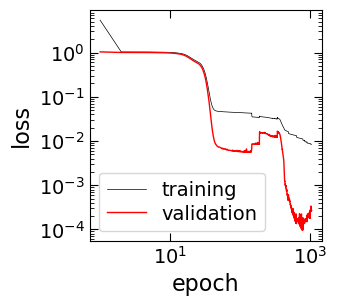

In [34]:
if Family == 'biseq':
    Optimize = True
    N_Lessons = np.min([10,setup_dict['max_epoch']])
    
    Example_Stem_Curriculum = Example_Root +'/curr'
    
    File_Stem = 'hyperopt/' + Example_Stem_Curriculum
    print('File_Stem:',File_Stem)

    Curriculum = (n_train // N_Lessons)*np.arange(1,N_Lessons+1)
    
    setup_dict_curr = copy.deepcopy(setup_dict)
    setup_dict_curr['file_stem'] = File_Stem
    setup_dict_curr['curriculum'] = Curriculum if Optimize else None
    setup_dict_curr['slowdowns'] = {'min':1.0,'max':1.5} 
    
    start_time = time()
    hopt_curr = HyperOpt(setup_dict=setup_dict_curr)
    
    if Optimize:
        binet_curr,params_train_curr,bts_curr = hopt_curr.optimize()
    else:
        binet_curr = hopt_curr.load()
        params_train_curr,bts = hopt_curr.load_train()
    
    ut.time_this(start_time)

    show_keys = ['La','wt_decay_a','n_layer_a','atypes_a',
                 'Lw','wt_decay_w','n_layer_w','atypes_w']
    
    print('Best test stat = {0:.3e}'.format(bts_curr))
    print('Setup params:')
    for pkey in show_keys:
        print('... '+pkey+':',binet_curr.params[pkey])
        if pkey == 'atypes':
            if 'lrelu' in binet_curr.params[pkey]:
                print('... ... lrelu_slope: {0:.2e}'.format(binet_curr.params['lrelu_slope']))
    print('... check_after: {0:d}'.format(params_train_curr['check_after']))
    for pkey in ['lrate_a','lrate_w','slowdown']:
        print('... '+pkey+': {0:.2e}'.format(params_train_curr[pkey]))

    N_free_curr = binet_curr.calc_N_freeparams()
    print('No. of free params optimized = {0:d}\n'.format(N_free_curr))
    
    plt.figure(figsize=(3,3))
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.plot(binet_curr.epochs,binet_curr.training_loss,'k-',lw=0.5,label='training')
    plt.plot(binet_curr.epochs,binet_curr.val_loss,'r-',lw=1,label='validation')
    plt.legend()
    plt.show()
    
    Ypred_curr = binet_curr.predict(X_test)
    residual_curr = np.squeeze(Ypred_curr/(Y_test + 1e-15) - 1)

##### Standard learning

File_Stem: hyperopt/biseq/gf1d/deep/stdXstdY/dn2/fixwid/std
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: BiSequential
... ... standard training will be implemented
... found data set of dimension = 3 (expecting n0a = 1, n0w = 2) with targets of dimension 1
... found 45000 samples
... fraction 0.800 (36000 samples) will be used for training
... will search over 2 iterations of 128 configurations
... will use mean squared error for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 16 process(es)
[....................] 100% done

... identifying and saving best network and its teststat and training params
223 min 37.90 seconds

Best test stat = 2.233e-03
Setup params:
... La: 10
... wt_decay_a: 0.003125
... n_layer_a: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
... atypes_a: [np.str_('relu'), np.str_('tanh'), np.str_('relu'), np.str_('splus'), np.str_('splus'),

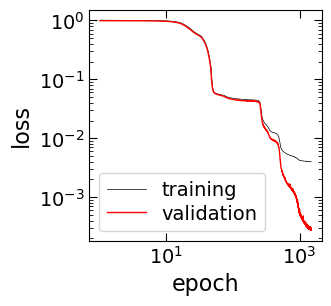

In [25]:
if Family == 'biseq':
    Optimize = True
    
    Example_Stem_Standard = Example_Root +'/std'
    
    File_Stem = 'hyperopt/' + Example_Stem_Standard
    print('File_Stem:',File_Stem)
    
    setup_dict_std = copy.deepcopy(setup_dict)
    setup_dict_std['file_stem'] = File_Stem
    
    start_time = time()
    hopt = HyperOpt(setup_dict=setup_dict_std)
    
    if Optimize:
        binet,params_train,bts = hopt.optimize()
    else:
        binet = hopt.load()
        params_train,bts = hopt.load_train()
    
    ut.time_this(start_time)

    show_keys = ['La','wt_decay_a','n_layer_a','atypes_a',
                 'Lw','wt_decay_w','n_layer_w','atypes_w']
    
    print('Best test stat = {0:.3e}'.format(bts))
    print('Setup params:')
    for pkey in show_keys:
        print('... '+pkey+':',binet.params[pkey])
        if pkey == 'atypes':
            if 'lrelu' in binet.params[pkey]:
                print('... ... lrelu_slope: {0:.2e}'.format(binet.params['lrelu_slope']))
    print('... check_after: {0:d}'.format(params_train['check_after']))
    for pkey in ['lrate_a','lrate_w']:
        print('... '+pkey+': {0:.2e}'.format(params_train_curr[pkey]))
    
    N_free_std = binet.calc_N_freeparams()
    print('No. of free params optimized = {0:d}\n'.format(N_free_std))
    
    plt.figure(figsize=(3,3))
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.plot(binet.epochs,binet.training_loss,'k-',lw=0.5,label='training')
    plt.plot(binet.epochs,binet.val_loss,'r-',lw=1,label='validation')
    plt.legend()
    plt.show()
    
    Ypred_std = binet.predict(X_test)
    residual_std = np.squeeze(Ypred_std/(Y_test + 1e-15) - 1)

#### Plot

Writing to file: hyperopt/plots/biseq_gf1d_deep_stdXstdY_dn2_fixwid.pdf
median +- 1sigma
...   standard: 0.0401 + 3.5698 - 1.5518 %
... curriculum: 0.0042 + 3.0719 - 1.8826 %


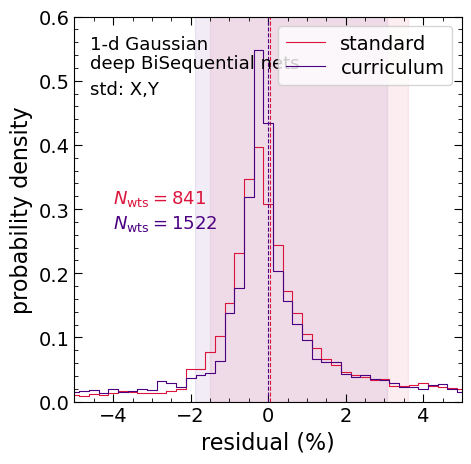

In [36]:
if Family == 'biseq':
    bins = np.linspace(-25,25,201)
    bin_mid = 0.5*(bins[1:]+bins[:-1])
    
    res_std_16pc = np.percentile(residual_std,16)*100
    res_std_med  = np.median(residual_std)*100
    res_std_84pc = np.percentile(residual_std,84)*100    
    hist_std,bins = np.histogram(residual_std*100,bins=bins,density=False)
    hist_std = hist_std/residual_std.size/(bins[1]-bins[0])
    
    res_curr_16pc = np.percentile(residual_curr,16)*100
    res_curr_med  = np.median(residual_curr)*100
    res_curr_84pc = np.percentile(residual_curr,84)*100
    hist_curr,bins = np.histogram(residual_curr*100,bins=bins,density=False)
    hist_curr = hist_curr/residual_curr.size/(bins[1]-bins[0])
    
    XLoc  = 5.0 if Ftype=='gf1d' else 8.0
    dXLoc = 0.4 if Ftype=='gf1d' else 0.5
    cols = ['crimson','indigo']
    plt.figure(figsize=(5,5))
    plt.xlim(-XLoc,XLoc)
    plt.ylim(0,6/10)
    plt.xlabel('residual (%)')
    plt.ylabel('probability density')
    
    plt.plot(bin_mid,hist_std,'-',c=cols[0],lw=0.8,drawstyle='steps',label='standard')
    plt.axvline(res_std_med,c=cols[0],ls='--',lw=0.8)
    plt.fill_betweenx(np.linspace(0,7,10),res_std_16pc,res_std_84pc,color=cols[0],alpha=0.075)
    
    plt.plot(bin_mid,hist_curr,'-',c=cols[1],lw=0.8,drawstyle='steps',label='curriculum')
    plt.axvline(res_curr_med,c=cols[1],ls='--',lw=0.8)
    plt.fill_betweenx(np.linspace(0,7,10),res_curr_16pc,res_curr_84pc,color=cols[1],alpha=0.075)
    plt.minorticks_on()
    plt.legend(loc='upper right')
    plt.text(-XLoc+dXLoc,5.5/10,Example_Text,fontsize=FS3)
    RanWid_Str = ' (ran wid)' if Fixed_Width==False else ''
    plt.text(-XLoc+dXLoc,5.2/10,Depth_Str_Root+RanWid_Str+' '+hopt.family_name+' nets',fontsize=FS3)
    plt.text(-XLoc+dXLoc,4.8/10,Std_Text,fontsize=FS3)
    plt.text(-XLoc+dXLoc*2.5,3.1/10,'$N_{{\\rm wts}} = {0:d}$'.format(N_free_std),fontsize=FS3,c=cols[0])
    plt.text(-XLoc+dXLoc*2.5,2.7/10,'$N_{{\\rm wts}} = {0:d}$'.format(N_free_curr),fontsize=FS3,c=cols[1])
    if Save_Fig:
        outfile = Plot_Stem + '/' + Plot_Root + '.pdf'
        print('Writing to file: '+outfile)
        plt.savefig(outfile,bbox_inches='tight')
    else:
        plt.show()
    
    print('median +- 1sigma')
    print('...   standard: {0:.4f} + {1:.4f} - {2:.4f} %'.format(res_std_med,res_std_84pc-res_std_med,res_std_med-res_std_16pc))
    print('... curriculum: {0:.4f} + {1:.4f} - {2:.4f} %'.format(res_curr_med,res_curr_84pc-res_curr_med,res_curr_med-res_curr_16pc))